# Generate SIMLIB file for SNANA simulations.

# Generate WFST SIMLIB from CSV

Use `OpSimSurvey.from_csv()` to load WFST observations, then the standard `opsimsummaryv2` pipeline to generate the SIMLIB.


In [1]:
# Reload opsimsummaryv2 to pick up source code changes
import importlib
import os
from pathlib import Path

import numpy as np
import opsimsummaryv2 as opsim
import opsimsummaryv2.summary_opsim
import opsimsummaryv2.sim_io
importlib.reload(opsimsummaryv2.summary_opsim)
importlib.reload(opsimsummaryv2.sim_io)
importlib.reload(opsim)

def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "scripts").exists() and (candidate / "notebooks").exists():
            return candidate
    return current

REPO_ROOT = find_repo_root()
WFST_SIMOBS_CSV = REPO_ROOT / "data" / "simobs" / "WFST_simobs_2.csv"
KN_SIMLIB_DIR = Path(os.environ.get("KN_SIMLIB_DIR", REPO_ROOT / "outputs" / "simlib")).expanduser()
LSST_OPSIM_DB = Path(os.environ.get("LSST_OPSIM_DB", REPO_ROOT / "data" / "external" / "baseline_v5.0.1_10yrs.db")).expanduser()
KN_SIMLIB_DIR.mkdir(parents=True, exist_ok=True)

# Load WFST observations from CSV (NaN rows are dropped automatically)
OpSimSurv_WFST = opsim.OpSimSurvey.from_csv(
    str(WFST_SIMOBS_CSV),
    pixel_size=0.333,        # WFST pixel size in arcsec
    field_radius_deg=1.5,    # WFST FOV radius in degrees
)


Reading from CSV data/simobs/WFST_simobs_2.csv
Dropped 3645 rows with NaN in ['seeingFwhmEff', 'fiveSigmaDepth', 'skyBrightness']
Read N = 55890 observations in 0.11 seconds.
No host file.


Finished compute healpy representation, total number of fields : 13378.
Total HEALPix fields in WFST survey: 13378


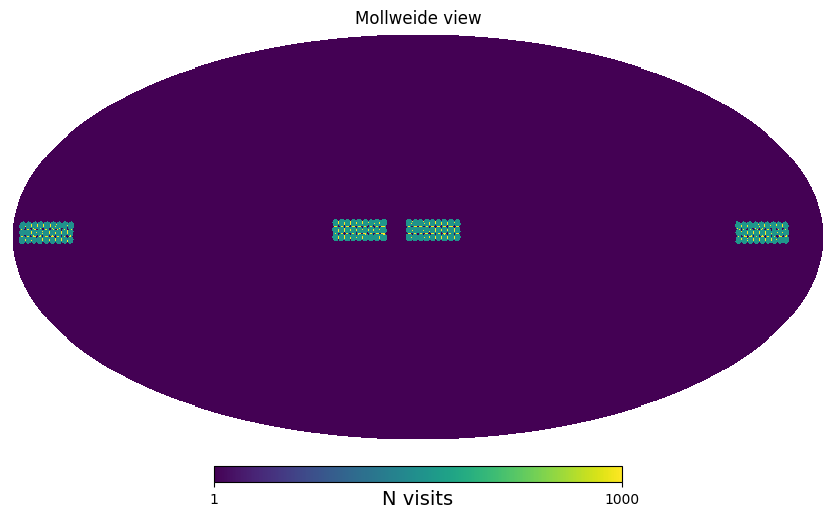

In [2]:
# Compute healpy representation for WFST
OpSimSurv_WFST.compute_hp_rep(nside=256, minVisits=1, maxVisits=100000, ddf_nobs_thresh=0, add_ddf_tag=True)
fig = OpSimSurv_WFST.plot_hp_rep(min=1, max=1000)

N_fields_wfst = len(OpSimSurv_WFST.hp_rep)
print(f"Total HEALPix fields in WFST survey: {N_fields_wfst}")


# Generate matched WFST + LSST SIMLIBs (same LIBID -> same sky position)

Restrict both surveys to their overlapping HEALPix footprint, then use `sample_coordinates()` to ensure the LSST SIMLIB has the same LIBID->(RA,DEC) mapping as WFST. With the same `RANSEED` in the INPUT files, `snlc_sim.exe` will generate the same transient at each LIBID.


In [3]:
# Load LSST opsim database
OpSimSurv_LSST = opsim.OpSimSurvey(str(LSST_OPSIM_DB))

# Compute LSST HEALPix representation (same nside as WFST)
OpSimSurv_LSST.compute_hp_rep(nside=256, minVisits=1, maxVisits=10000)
print(f"Full LSST footprint: {len(OpSimSurv_LSST.hp_rep)} HEALPix fields")

# Find overlapping HEALPix pixels between WFST and LSST
wfst_ipix = set(OpSimSurv_WFST.hp_rep.index)
lsst_ipix = set(OpSimSurv_LSST.hp_rep.index)
overlap_ipix = sorted(wfst_ipix & lsst_ipix)
print(f"WFST fields: {len(wfst_ipix)}, LSST fields: {len(lsst_ipix)}")
print(f"Overlapping HEALPix fields: {len(overlap_ipix)}")
print(f"WFST-only fields (no LSST): {len(wfst_ipix - lsst_ipix)}")

# Restrict WFST hp_rep to overlap-only pixels (so both SIMLIBs have same fields)
import healpy as hp
OpSimSurv_WFST._hp_rep = OpSimSurv_WFST._hp_rep.loc[
    OpSimSurv_WFST._hp_rep.index.isin(overlap_ipix)
]
OpSimSurv_WFST._hp_rep.attrs["nside"] = 256
OpSimSurv_WFST._hp_rep.attrs["survey_area_deg"] = hp.nside2pixarea(256, degrees=True) * len(overlap_ipix)
OpSimSurv_WFST._hp_rep.attrs["survey_area_rad"] = hp.nside2pixarea(256, degrees=False) * len(overlap_ipix)

# Restrict LSST hp_rep to the same overlap pixels
OpSimSurv_LSST._hp_rep = OpSimSurv_LSST._hp_rep.loc[
    OpSimSurv_LSST._hp_rep.index.isin(overlap_ipix)
]
OpSimSurv_LSST._hp_rep.attrs["nside"] = 256
OpSimSurv_LSST._hp_rep.attrs["survey_area_deg"] = hp.nside2pixarea(256, degrees=True) * len(overlap_ipix)
OpSimSurv_LSST._hp_rep.attrs["survey_area_rad"] = hp.nside2pixarea(256, degrees=False) * len(overlap_ipix)

print("\nAfter overlap cut:")
print(f"  WFST fields: {len(OpSimSurv_WFST.hp_rep)}")
print(f"  LSST fields: {len(OpSimSurv_LSST.hp_rep)}")
print(f"  Overlap area: {OpSimSurv_WFST.hp_rep.attrs['survey_area_deg']:.1f} deg^2")


Reading from database sqlite:///data/external/baseline_v5.0.1_10yrs.db


Read N = 2092088 observations in 27.59 seconds.
No host file.
Finished compute healpy representation, total number of fields : 535248.
Full LSST footprint: 535248 HEALPix fields
WFST fields: 13378, LSST fields: 535248
Overlapping HEALPix fields: 13334
WFST-only fields (no LSST): 44

After overlap cut:
  WFST fields: 13334
  LSST fields: 13334
  Overlap area: 699.4 deg^2


In [4]:
# Sample WFST fields (overlap only) - this defines the LIBID ordering
N_overlap = len(OpSimSurv_WFST.hp_rep)
OpSimSurv_WFST.sample_survey(N_overlap, random_seed=1234)

# Extract RA/DEC from the WFST survey in LIBID order
wfst_ra = np.degrees(OpSimSurv_WFST.survey["hp_ra"].values)
wfst_dec = np.degrees(OpSimSurv_WFST.survey["hp_dec"].values)
print(f"WFST survey fields: {len(wfst_ra)}")

# Sample LSST using the exact same coordinates -> same LIBID ordering
OpSimSurv_LSST.sample_coordinates(wfst_ra, wfst_dec, nsides=256, is_deg=True)
print(f"LSST survey fields: {len(OpSimSurv_LSST.survey)}")

# Verify LIBID 0 has the same RA/DEC in both
print(f"\nLIBID 0 check:")
print(f"  WFST  RA={wfst_ra[0]:.4f} DEC={wfst_dec[0]:.4f}")
lsst_ra0 = np.degrees(OpSimSurv_LSST.survey["hp_ra"].values[0])
lsst_dec0 = np.degrees(OpSimSurv_LSST.survey["hp_dec"].values[0])
print(f"  LSST  RA={lsst_ra0:.4f} DEC={lsst_dec0:.4f}")


WFST survey fields: 13334
LSST survey fields: 13334

LIBID 0 check:
  WFST  RA=170.1562 DEC=5.2295
  LSST  RA=170.1562 DEC=5.2295


In [5]:
# Write WFST SIMLIB (overlap footprint)
sim_wfst = opsim.sim_io.SNANA_Simlib(
    OpSimSurv_WFST,
    out_path=str(KN_SIMLIB_DIR) + "/",
    survey_name="WFST",
    filters="ugr",
    telescope="WFST",
    CCDnoise=0.0,
)
sim_wfst.write_SIMLIB()

# Write LSST SIMLIB (same footprint, matched LIBIDs)
sim_lsst = opsim.sim_io.SNANA_Simlib(
    OpSimSurv_LSST,
    out_path=str(KN_SIMLIB_DIR) + "/",
    file_suffix="_WFSTfootprint",
    survey_name="LSST",
    filters="ugrizY",
    telescope="LSST",
)
sim_lsst.write_SIMLIB()


Writing SIMLIB in outputs/simlib/WFST_simobs_2.SIMLIB


SIMLIB wrote in 59.75 sec.

Writing SIMLIB in outputs/simlib/baseline_v5.0.1_10yrs_WFSTfootprint.SIMLIB
SIMLIB wrote in 73.77 sec.



In [6]:
import subprocess

# Verify both SIMLIBs
for label, sim in [("WFST", sim_wfst), ("LSST", sim_lsst)]:
    out = sim.out_path
    result = subprocess.run(["grep", "-c", "nan", str(out)], capture_output=True, text=True)
    nan_count = int(result.stdout.strip()) if result.returncode == 0 else 0
    print(f"{label} SIMLIB: {out}")
    print(f"  NaN lines: {nan_count}")

# Verify matching LIBID 0 RA/DEC between the two SIMLIBs
print("\n--- LIBID matching check (first 5 LIBIDs) ---")
for path, label in [(sim_wfst.out_path, "WFST"), (sim_lsst.out_path, "LSST")]:
    result = subprocess.run(["grep", "-A1", "^LIBID:", str(path)], capture_output=True, text=True)
    lines = result.stdout.strip().split("\n")
    print(f"\n{label}:")
    count = 0
    for line in lines:
        if "LIBID:" in line or "RA:" in line:
            print(f"  {line.strip()}")
            if "RA:" in line:
                count += 1
        if count >= 5:
            break


WFST SIMLIB: outputs/simlib/WFST_simobs_2.SIMLIB
  NaN lines: 0
LSST SIMLIB: outputs/simlib/baseline_v5.0.1_10yrs_WFSTfootprint.SIMLIB
  NaN lines: 0

--- LIBID matching check (first 5 LIBIDs) ---

WFST:
  LIBID:          0
  RA: +170.156250 DEC:  +5.229529   NOBS:        504 MWEBV:  0.00 PIXSIZE: 0.333 FIELD: DDF_UNKNOWN
  LIBID:          1
  RA: +154.160156 DEC:  -0.298417   NOBS:        504 MWEBV:  0.00 PIXSIZE: 0.333 FIELD: DDF_COSMOS
  LIBID:          2
  RA: +197.050781 DEC:  -0.596842   NOBS:        525 MWEBV:  0.00 PIXSIZE: 0.333 FIELD: DDF_UNKNOWN
  LIBID:          3
  RA: +165.410156 DEC:  +4.181528   NOBS:        504 MWEBV:  0.00 PIXSIZE: 0.333 FIELD: DDF_UNKNOWN
  LIBID:          4
  RA: +350.332031 DEC:  +0.895283   NOBS:        516 MWEBV:  0.00 PIXSIZE: 0.333 FIELD: DDF_UNKNOWN

LSST:
  LIBID:          0
  RA: +170.156250 DEC:  +5.229529   NOBS:        804 MWEBV:  0.00 PIXSIZE: 0.200 FIELD: WFD
  LIBID:          1
  RA: +154.160156 DEC:  -0.298417   NOBS:        866 MWEBV

In [7]:
# Summary: matched SIMLIB parameters for INPUT files
solid_angle = OpSimSurv_LSST._hp_rep.attrs['survey_area_rad']
n_fields = len(OpSimSurv_WFST.survey)
print(f"NLIBID (both SIMLIBs): {n_fields}")
print(f"SOLID_ANGLE: {solid_angle:.3f} sr")
print(f"Overlap area: {OpSimSurv_LSST._hp_rep.attrs['survey_area_deg']:.1f} deg^2")
print(f"\nUse SOLID_ANGLE: {solid_angle:.3f} and same RANSEED in both INPUT files.")


NLIBID (both SIMLIBs): 13334
SOLID_ANGLE: 0.213 sr
Overlap area: 699.4 deg^2

Use SOLID_ANGLE: 0.213 and same RANSEED in both INPUT files.
